In [1]:
## Script to visualize Intrinsic Plasticity training results

# Import packages and libraries
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec
from sklearn.neighbors import KernelDensity

import os
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy import stats

In [22]:
# Define file path and names
IP = True
if IP:
    #filename = 'sweep_results3.csv'
    # filename = 'C:/Users/rikki/Thesis/sweep_results_nsynth.csv'
    filename = 'D:/Data/THESIS RESULTS/Deep NSynth params [COMPLETE]/full_results.csv'
else:
    filename = 'sweep_results_stochastic.csv'
    
dirfile = '/Users/kikivanderheijden/Library/CloudStorage/OneDrive-RadboudUniversiteit/RU-Drive/DocumentsKiki/Teaching/RadboudUniversity/Master_Theses/2025-2026_RikJansen_Internal'
dirfig = '/Users/kikivanderheijden/Library/CloudStorage/OneDrive-RadboudUniversiteit/RU-Drive/DocumentsKiki/Teaching/RadboudUniversity/Master_Theses/2025-2026_RikJansen_InternalFigures'

In [23]:
# Functions
def create_overview_parameters(data):
    
    # Create a list with parameter names and number of values per parameter
    params = data.keys() # this generates an object
    
    param_list = [i for i in params] # convert to list
    param_uniquevals = [data[i].unique() for i in param_list] # extract unique values

    # concatenate to list
    param_overview = [param_list,param_uniquevals]

    return param_overview

def model_gauss(x, a, b, c):
    return a * np.exp(-(((x-b)**2)/(2*c**2)))

def gauscurvefits(x, bin_edges, n_samples_curvefit, x_vect_preds, x_vect_preds_gof):
    counts_all = np.zeros((np.shape(x)[0],len(bin_edges)-1))
    preds_all = np.zeros((np.shape(x)[0],n_samples_curvefit))
    preds_gof_all = np.zeros((np.shape(x)[0],len(bin_edges)))

    bin_center = bin_edges + (1/(2*len(bin_edges))) # identify bin centers for curve fit
    counts,_ = np.histogram(x, bins = bin_edges) # extract histogram
    popt, _ = sp.optimize.curve_fit(model_gauss, bin_center[:-1], counts, p0 = [max(counts),1,1]) # fit gaussian curve
    # create model predictions
    preds = model_gauss(x_vect_preds, popt[0], popt[1], popt[2])
    preds_gof = model_gauss(x_vect_preds_gof, popt[0],popt[1],popt[2])

    return counts, preds, preds_gof, popt

def interpcurves(x, bin_edges, num_samp, x_vect_preds):
    n_groups = len(x)

    counts_all = np.zeros((n_groups, len(bin_edges) - 1))
    preds_all = np.zeros((n_groups, num_samp))

    for i, arr in enumerate(x):
        counts, _ = np.histogram(arr, bins=bin_edges)
        counts_all[i] = counts

        finterp = sp.interpolate.interp1d(
            bin_edges[:-1],
            counts,
            kind="cubic",
            fill_value="extrapolate"
        )

        preds_all[i] = finterp(x_vect_preds)

    return counts_all, preds_all


In [24]:
# extract distributions for data
numbins = 100
bin_edges = np.linspace(0,1, num = numbins, endpoint = True)
n_samples_curvefit = 400
x_vect_preds = np.linspace(min(bin_edges),max(bin_edges),n_samples_curvefit) - 1/(numbins*2) # define bin center
x_vect_preds_gof = np.linspace(min(bin_edges),max(bin_edges),len(bin_edges)) - 1/(numbins*2)

In [25]:
# load csv file 
results = pd.read_csv(filename)
# results = results[~results["lr"].isin([0.2, 0.4])]
results_sub = results[results["sr"] == 0.8]

# extract information about the parameters assessed
param_overview = create_overview_parameters(results)

In [6]:
results["N"] = 1200

In [26]:
if IP:
    grouped = (
        results
        .groupby(["N", "sr", "lr", "sigma"])["accuracy"]
        .apply(lambda x: x.to_numpy())
    )
else:
    grouped = (
        results
        .groupby(["N", "sr", "lr"])["accuracy"]
        .apply(lambda x: x.to_numpy())
    )

In [27]:
print(grouped.index.names)

['N', 'sr', 'lr', 'sigma']


In [28]:
lengths = grouped.apply(len)
print(lengths)
print(lengths.unique())

N     sr   lr    sigma
800   0.4  0.94  0.1      25
                 0.2      25
                 0.3      25
           0.97  0.1      25
                 0.2      25
                          ..
1200  0.8  0.97  0.2      25
                 0.3      25
           1.00  0.1      25
                 0.2      25
                 0.3      25
Name: accuracy, Length: 93, dtype: int64
[25 35 37 36 38]


In [29]:
if IP:  
    Ns = sorted(results["N"].unique())
    srs = sorted(results["sr"].unique())
    lrs = sorted(results["lr"].unique())
    sigmas = sorted(results["sigma"].unique())
else:
    Ns = sorted(results["N"].unique())
    srs = sorted(results["sr"].unique())
    lrs = sorted(results["lr"].unique())

In [30]:
def filter_grouped(grouped, N=None, sr=None, lr=None, sigma=None):
    filters = {
        "N": N,
        "sr": sr,
        "lr": lr,
        "sigma": sigma,
    }

    data_fit = []

    for params, arr in grouped.items():
        param_dict = dict(zip(grouped.index.names, params))

        keep = all(
            value is None or param_dict[name] == value
            for name, value in filters.items()
            if name in param_dict
        )

        if keep:
            remaining_params = tuple(
                param_dict[name]
                for name, value in filters.items()
                if value is None and name in param_dict
            )
            data_fit.append((remaining_params, arr))

    return data_fit
    
def filter_grouped(grouped, N=None, sr=None, lr=None, sigma=None):
    filters = {
        "N": N,
        "sr": sr,
        "lr": lr,
        "sigma": sigma,
    }

    data_fit = []

    for params, arr in grouped.items():
        param_dict = dict(zip(grouped.index.names, params))

        keep = all(
            value is None or param_dict[name] == value
            for name, value in filters.items()
            if name in param_dict
        )

        if keep:
            remaining_params = tuple(
                param_dict[name]
                for name, value in filters.items()
                if value is None and name in param_dict
            )
            data_fit.append((remaining_params, arr))

    return data_fit

In [34]:
def make_ridgeline_plot(N=None, sigma=None):
    data_list = filter_grouped(grouped, N=N, sigma=sigma)

    # Sort existing combinations only
    data_list = sorted(data_list, key=lambda x: x[0])

    params_list = [p for p, _ in data_list]
    data_arrays = [arr for _, arr in data_list]

    print(grouped.index.names)
    print(params_list[:10])

    print(f"{len(data_arrays)} parameter combinations found")

    data, pred = interpcurves(
        data_arrays,
        bin_edges,
        n_samples_curvefit,
        x_vect_preds
    )

    fig = plt.figure(figsize=(16, max(5, len(data_arrays) * 0.28)))
    gs = grid_spec.GridSpec(len(data_arrays), 1)

    colors = sns.color_palette("crest", len(data_arrays))
    ax_objs = []

    for i, (params, arr) in enumerate(zip(params_list, data_arrays)):
        ax = fig.add_subplot(gs[i:i+1, 0:])
        ax_objs.append(ax)

        ax.plot(x_vect_preds, pred[i], color="#f0f0f0", lw=1)
        ax.fill_between(x_vect_preds, pred[i], alpha=1, color=colors[i])

        ax.set_xlim(0, 1)
        ax.set_ylim(0, max(pred[i]) * 1.05)

        ax.tick_params(axis="x", labelsize=16)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}"))

        ax.patch.set_alpha(0)
        ax.set_yticks([])
        ax.set_yticklabels([])

        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)

        if i == len(data_arrays) - 1:
            ax.set_xlabel("Accuracy (%)", fontsize=16, fontweight="bold")
        else:
            ax.set_xticklabels([])

        ax.grid(False)

        # Dynamic label depending on remaining parameters
        label = ", ".join(
            f"{name}={value:.2f}" if isinstance(value, float) else f"{name}={value}"
            for name, value in zip(
                [n for n in grouped.index.names if not ((n == "N" and N is not None) or (n == "sigma" and sigma is not None))],
                params
            )
        )

        sr, lr = params[:2]
        
        ax.text(
            -0.13, 0,
            f"{sr:.2f}",
            ha="center",
            va="center",
            fontsize=14,
            transform=ax.transAxes
        )
        
        ax.text(
            -0.07, 0,
            f"{lr:.2f}",
            ha="center",
            va="center",
            fontsize=14,
            transform=ax.transAxes
        )
    
    gs.update(hspace=-0.2)

    # Column headers
    ax_objs[0].text(
        -0.13, 1.2, "SR",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        transform=ax_objs[0].transAxes
    )
    
    ax_objs[0].text(
        -0.07, 1.2, "LR",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        transform=ax_objs[0].transAxes
    )
    
    # Vertical side label
    fig.text(
        0.055, 0.5, # position
        "Parameter Sets",
        rotation=90,
        va="center",
        ha="center",
        fontsize=15,
        fontweight="bold"
    )

    title = f"Accuracy distribution per parameter set"
    if N is not None:
        title += fr" ($N$ = {N})"
    if sigma is not None:
        title += fr" ($\sigma$ = {sigma})"

    fig.suptitle(title, fontsize=18, y=0.87, fontweight='bold')
    
    plt.subplots_adjust(left=0.18, top=0.8)
    plt.show()

['N', 'sr', 'lr', 'sigma']
[(0.2, 0.2), (0.2, 0.4), (0.4, 0.2), (0.4, 0.4), (0.4, 0.94), (0.4, 0.97), (0.4, 1.0), (0.6, 0.94), (0.6, 0.97), (0.6, 1.0)]
13 parameter combinations found


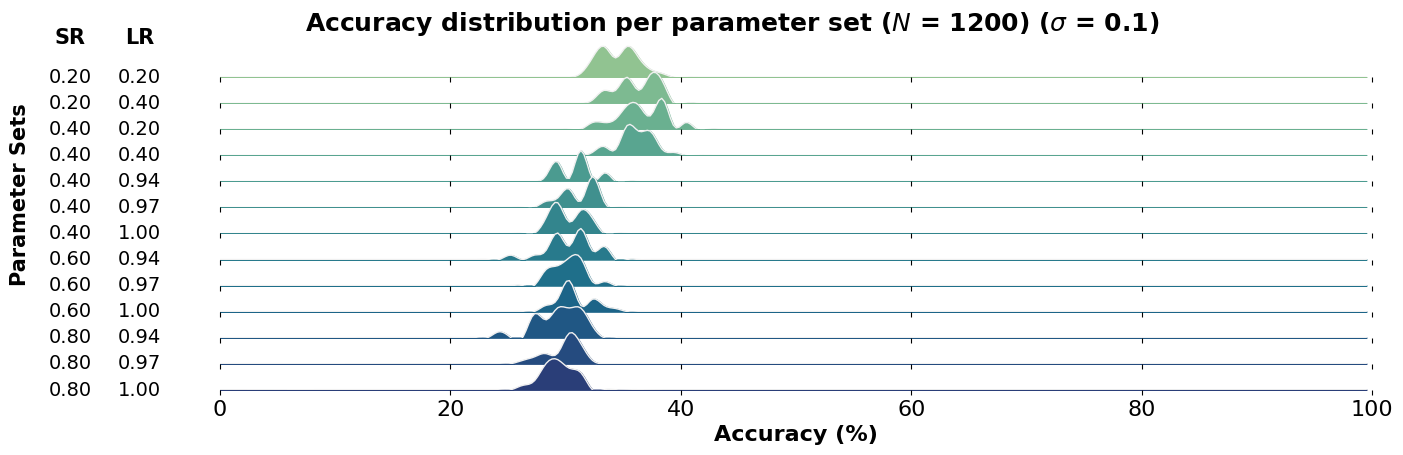

In [38]:
# Make ridgeline plots
make_ridgeline_plot(1200, 0.1)

In [39]:
sr_stats = (
    results.groupby("sr")["accuracy"]
    .agg(["mean", "std", "count"])
    .sort_index()
)

lr_stats = (
    results.groupby("lr")["accuracy"]
    .agg(["mean", "std", "count"])
    .sort_index()
)

sigma_stats = (
    results.groupby("sigma")["accuracy"]
    .agg(["mean", "std", "count"])
    .sort_index()
)

print(sr_stats)
print(lr_stats)
print(sigma_stats)

         mean       std  count
sr                            
0.2  0.358041  0.018645    217
0.4  0.319124  0.030355    896
0.6  0.301289  0.016888    675
0.8  0.294570  0.017270    675
          mean       std  count
lr                             
0.20  0.359178  0.019937    219
0.40  0.362877  0.017345    219
0.94  0.300170  0.016869    675
0.97  0.300711  0.017160    675
1.00  0.299422  0.017093    675
           mean       std  count
sigma                           
0.1    0.309841  0.030137    819
0.2    0.310583  0.028878    823
0.3    0.312381  0.028089    821


In [40]:
sr_lr_stats = (
    results
    .groupby(["sr", "lr"])["accuracy"]
    .agg(["mean", "std", "count"])
    .sort_index()
)

print(sr_lr_stats)

              mean       std  count
sr  lr                             
0.2 0.20  0.352850  0.018328    107
    0.40  0.363091  0.017609    110
0.4 0.20  0.365223  0.019606    112
    0.40  0.362661  0.017154    109
    0.94  0.304178  0.015623    225
    0.97  0.304822  0.016311    225
    1.00  0.304333  0.014307    225
0.6 0.94  0.300489  0.016903    225
    0.97  0.302022  0.016140    225
    1.00  0.301356  0.017629    225
0.8 0.94  0.295844  0.017073    225
    0.97  0.295289  0.017641    225
    1.00  0.292578  0.016989    225


In [41]:
import statistics

if IP:
    def calculate_gof(sr):
        data_fit = []
        
        data_list = filter_grouped(grouped, sr=sr)
    
        for i, (params_meta, reservoir_data) in enumerate(data_list):
            N, lr, sigma = params_meta
             
            test_counts, test_preds, test_preds_gof, test_params = gauscurvefits(reservoir_data, bin_edges, n_samples_curvefit, x_vect_preds, x_vect_preds_gof)
            # Evaluate goodness of fit with r-squared and rmse 
            diff_mean_obs = test_counts - np.mean(test_counts)
            res = test_counts - test_preds_gof[:-1] # calculate residuals 
            rsq = 1-((np.sum(np.square(res)))/np.sum((np.square(diff_mean_obs)))) # calculate R squared
            rmse = np.sqrt(np.sum(np.square(res))/(len(res)-len(test_params))) # calculate rmse it's divided by the degrees of freedom of the error, which is N (obersvations) - number of parameter estimates
            
            print(f"Params: N={N}, lr={lr}, sigma={sigma}")
            print("Task performance (average, variance) = " + str(round(test_params[1]*100,1)) + ", " + str(round(test_params[2]*100,2)))
            print("Goodness of fit statistics: RMSE = " + str(round(rmse,2)) + ", R2 = " + str(round(rsq,3)))
            print(f"Median: {statistics.median(reservoir_data)}" + '\n')
else:
    def calculate_gof(sr):
        data_fit = []
        
        data_list = filter_grouped(grouped, sr=sr)
    
        for i, (params_meta, reservoir_data) in enumerate(data_list):
            N, lr = params_meta
             
            test_counts, test_preds, test_preds_gof, test_params = gauscurvefits(reservoir_data, bin_edges, n_samples_curvefit, x_vect_preds, x_vect_preds_gof)
            # Evaluate goodness of fit with r-squared and rmse 
            diff_mean_obs = test_counts - np.mean(test_counts)
            res = test_counts - test_preds_gof[:-1] # calculate residuals 
            rsq = 1-((np.sum(np.square(res)))/np.sum((np.square(diff_mean_obs)))) # calculate R squared
            rmse = np.sqrt(np.sum(np.square(res))/(len(res)-len(test_params))) # calculate rmse it's divided by the degrees of freedom of the error, which is N (obersvations) - number of parameter estimates
            
            print(f"Params: N={N}, lr={lr}")
            print("Task performance (average, variance) = " + str(round(test_params[1]*100,1)) + ", " + str(round(test_params[2]*100,2)))
            print("Goodness of fit statistics: RMSE = " + str(round(rmse,2)) + ", R2 = " + str(round(rsq,3)))
            print(f"Median: {statistics.median(reservoir_data)}" + '\n')

In [88]:
calculate_gof(0.4)

Params: N=800, lr=0.94, sigma=0.1
Task performance (average, variance) = 28.8, -1.12
Goodness of fit statistics: RMSE = 0.72, R2 = 0.616
Median: 0.29

Params: N=800, lr=0.94, sigma=0.2
Task performance (average, variance) = 29.8, -1.79
Goodness of fit statistics: RMSE = 0.61, R2 = 0.681
Median: 0.295

Params: N=800, lr=0.94, sigma=0.3
Task performance (average, variance) = 29.9, 1.26
Goodness of fit statistics: RMSE = 0.71, R2 = 0.674
Median: 0.3

Params: N=800, lr=0.97, sigma=0.1
Task performance (average, variance) = 29.7, 1.67
Goodness of fit statistics: RMSE = 0.51, R2 = 0.768
Median: 0.295

Params: N=800, lr=0.97, sigma=0.2
Task performance (average, variance) = 29.1, 1.81
Goodness of fit statistics: RMSE = 0.64, R2 = 0.665
Median: 0.29

Params: N=800, lr=0.97, sigma=0.3
Task performance (average, variance) = 30.1, 1.68
Goodness of fit statistics: RMSE = 0.61, R2 = 0.708
Median: 0.3

Params: N=800, lr=1.0, sigma=0.1
Task performance (average, variance) = 29.3, -1.16
Goodness of fi

In [84]:
from matplotlib.lines import Line2D

if IP:
    def curve_fits(N, sr):
        data_list = filter_grouped(grouped, N=N, sr=sr)
        print(grouped.index.names)
        print(data_list[0][0])

        # Sort existing combinations only
        data_list = sorted(data_list, key=lambda x: x[0])
    
        # unpack
        params_list = [p for p, _ in data_list]
        data_fit = [arr for _, arr in data_list]

        handles = []
        labels = []
        
        #colors = ["#8cc5e3","#2066a8","#d8a6a6","#a00000","#9fc8c8","#1f6f6f", "#f2c391", "#fc9423"] # groups of 2
        colors = ["#8cc5e3","#3594cc","#2066a8","#d8a6a6","#c46666","#a00000","#9fc8c8","#54a1a1","#1f6f6f", "#f2c391", "#fab266", "#fc9423",
                 "#f0eaaf", "#f5ea71", "#fce80a"] # groups of 3
        #colors = sns.color_palette("crest", len(data_fit))
        
        fig, axs = plt.subplots(figsize=(13,6))
        
        for i in range(len(data_fit)):
            test_counts, test_preds, test_preds_gof, test_params = gauscurvefits(data_fit[i], bin_edges, n_samples_curvefit, x_vect_preds, x_vect_preds_gof)
            lr, sigma = params_list[i]
            
            plt.hist(data_fit[i], bin_edges, alpha = 0.2, color = colors[i]);
            plt.plot(x_vect_preds, test_preds, color = colors[i], linewidth = 4, label=f"lr={lr:.2f}, σ={sigma}")
            plt.plot([test_params[1], test_params[1]], [0, 25], linestyle = "dashed", color = colors[i], linewidth = 4)
            
            handles.append(Line2D([0], [0], color=colors[i], lw=4))
            labels.append(f"{lr:.2f}     {sigma}")

        legend = plt.legend(handles, labels, title="       LR        σ", loc="upper left")
        legend.get_title().set_fontweight("bold")
        
        plt.xlim([0.26, 0.36])
        plt.ylim([0, 25])
        axs.tick_params(axis='x', labelsize=11)
        axs.tick_params(axis='y', labelsize=11)
        axs.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}"))
        
        plt.xlabel("Accuracy (%)", fontsize=14, fontweight="bold")
        plt.ylabel("Count", fontsize=14, fontweight="bold")
        plt.title(fr"Curve fits for each parameter set ($SR$ = {sr})", fontsize=14, fontweight="bold")
        # plt.savefig(f"plots/curvefits_{N}_{sr}.png")

['N', 'sr', 'lr', 'sigma']
(0.94, 0.1)


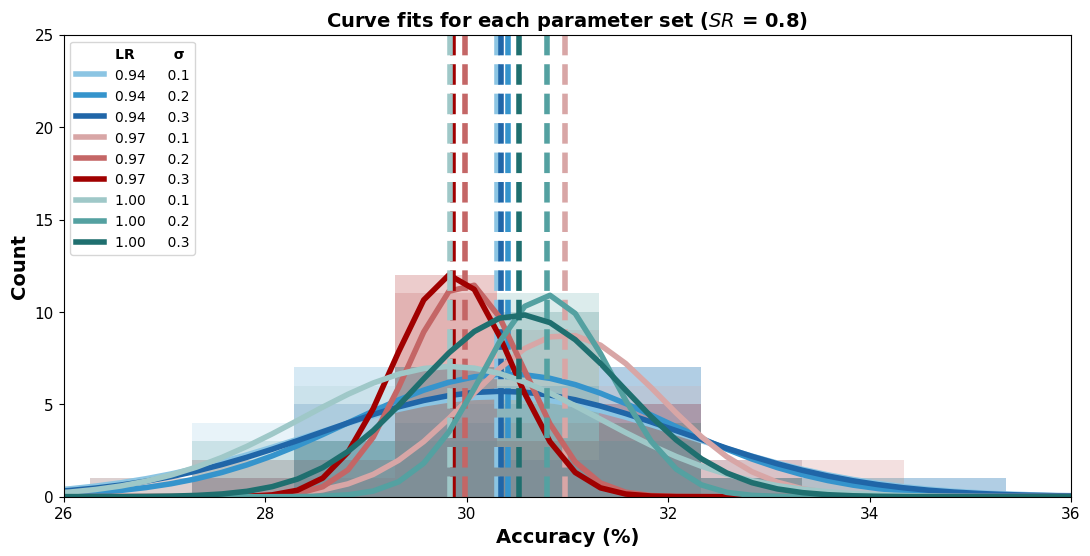

In [86]:
curve_fits(1200, 0.8)

In [ ]:
stats_by_sr = (
    results
    .groupby("sr")["accuracy"]
    .agg(
        mean_accuracy="mean",
        var_accuracy="var",
        std_accuracy="std",
        count="count",
    )
    .reset_index()
)
print(stats_by_sr)

In [184]:
for N in Ns:
    #make_ridgeline_plot(N, 0.1)
    make_ridgeline_plot(N, 0.94)
    # make_ridgeline_plot(N, 0.2)
    # make_ridgeline_plot(N, 0.3)

['N', 'sr', 'lr', 'sigma']
[]
0 parameter combinations found


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x500 with 0 Axes>